# CIFAR-10 이미지 분류 CNN 모델 — 최신 PyTorch 코드

이 노트북은 CIFAR-10 이미지 데이터를 사용하여 CNN 기반 이미지 분류 모델을 학습하고 평가하는 예제입니다.

구성은 다음 순서로 되어 있습니다.

1. 실행 환경 확인
2. 라이브러리 불러오기
3. 하이퍼파라미터 설정
4. CIFAR-10 데이터셋 준비
5. 샘플 이미지 시각화
6. CNN 모델 설계
7. 손실함수와 최적화 알고리즘 설정
8. 모델 학습
9. 모델 평가
10. 혼동행렬과 클래스별 정확도 확인
11. 예측 결과 시각화


In [ ]:
# 현재 노트북에서 사용할 주요 라이브러리를 불러옵니다.
# torch는 PyTorch의 핵심 패키지로, 텐서 연산과 딥러닝 모델 학습에 사용됩니다.
import torch

# torch.nn은 신경망 계층, 활성화 함수, 손실함수 등을 제공하는 모듈입니다.
import torch.nn as nn

# torch.optim은 SGD, Adam, AdamW 같은 최적화 알고리즘을 제공하는 모듈입니다.
import torch.optim as optim

# DataLoader는 데이터셋을 미니배치 단위로 나누어 모델에 공급하는 도구입니다.
from torch.utils.data import DataLoader

# torchvision은 이미지 데이터셋, 이미지 변환, 사전학습 모델 등을 제공하는 패키지입니다.
import torchvision

# torchvision.transforms는 이미지 데이터를 텐서로 바꾸거나 정규화하는 전처리 기능을 제공합니다.
import torchvision.transforms as transforms

# torchvision.datasets.CIFAR10은 CIFAR-10 데이터셋을 쉽게 내려받고 사용할 수 있게 해줍니다.
from torchvision.datasets import CIFAR10

# numpy는 혼동행렬 계산 등 수치 연산에 사용됩니다.
import numpy as np

# matplotlib.pyplot은 이미지와 그래프를 출력하는 데 사용됩니다.
import matplotlib.pyplot as plt

# time은 학습 시간 측정에 사용됩니다.
from time import time

# 운영체제별 DataLoader 설정을 안전하게 처리하기 위해 os 모듈을 사용합니다.
import os

# PyTorch 버전을 출력하여 현재 실행 환경을 확인합니다.
print("PyTorch version:", torch.__version__)

# CUDA 사용 가능 여부를 확인합니다.
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


## 1. 하이퍼파라미터 설정

하이퍼파라미터는 모델이 학습되기 전에 사람이 직접 정하는 값입니다.  
대표적으로 학습 횟수, 배치 크기, 학습률 등이 있습니다.


## 실습문제 1 : epochs 를 20 이상으로 늘리기


## 실습문제 4 : 아담의 LR을 0.0005, 0.0003 등으로 조정

In [ ]:
# 재현 가능한 실험을 위해 난수 시드를 고정합니다.
# 같은 코드를 다시 실행했을 때 가능한 한 비슷한 결과가 나오도록 도와줍니다.
SEED = 111

# PyTorch의 CPU 난수 생성 시드를 고정합니다.
torch.manual_seed(SEED)

# GPU가 있을 경우 GPU 난수 생성 시드도 고정합니다.
torch.cuda.manual_seed_all(SEED)

# 에포크는 전체 학습 데이터를 몇 번 반복해서 학습할지 정하는 값입니다.
# 처음 실습할 때는 2~5 정도로 작게 두고, 성능 개선 실험에서는 더 크게 늘릴 수 있습니다.
EPOCHS = 5
# EPOCHS = 20

# 배치 크기는 한 번의 학습 단계에서 모델에 넣는 이미지 개수입니다.
# CIFAR-10은 이미지가 작기 때문에 64 또는 128을 자주 사용합니다.
BATCH_SIZE = 64
# BATCH_SIZE = 128

# 학습률은 가중치를 한 번 업데이트할 때 얼마나 크게 움직일지 정하는 값입니다.
# 너무 크면 학습이 불안정하고, 너무 작으면 학습이 느려질 수 있습니다.
LEARNING_RATE = 0.001
# LEARNING_RATE = 0.0005
# LEARNING_RATE = 0.0003

# CIFAR-10 데이터셋을 저장할 폴더 경로입니다.
DATA_ROOT = "./cifar"

# GPU가 사용 가능하면 cuda를 사용하고, 그렇지 않으면 cpu를 사용합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 현재 모델 학습에 사용할 장치를 출력합니다.
print("사용 장치:", device)

# Windows 또는 Colab 환경에서 안정적으로 동작하도록 num_workers를 설정합니다.
# Windows에서 문제가 생기면 0을 사용하는 것이 가장 안전합니다.
NUM_WORKERS = 2 if os.name != "nt" else 0

# DataLoader가 GPU로 데이터를 더 빠르게 옮길 수 있도록 pin_memory 설정을 지정합니다.
PIN_MEMORY = True if torch.cuda.is_available() else False

사용 장치: cuda


## 2. 데이터 준비

CIFAR-10은 32×32 크기의 컬러 이미지 데이터셋입니다.  
총 10개의 클래스로 구성되어 있으며, 각 이미지는 RGB 3채널을 가집니다.

클래스는 다음과 같습니다.

`airplane`, `automobile`, `bird`, `cat`, `deer`, `dog`, `frog`, `horse`, `ship`, `truck`


## 실습문제 5. `RandomRotation`, `ColorJitter` 같은 데이터 증강을 추가합니다.

In [ ]:
import os
import tarfile
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

# 0. 환경 변수 및 설정 정의 (사용자 환경에 맞게 조절)
DATA_ROOT = "./data"          # 데이터가 저장될 최상위 디렉토리
BATCH_SIZE = 64
NUM_WORKERS = 2
PIN_MEMORY = True

# CIFAR-10 클래스 이름
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

# 전처리 설정
mean, std = [0.5, 0.5, 0.5], [0.5, 0.5, 0.5]
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# 실습문제 5
# 학습 데이터에 적용할 이미지 전처리 규칙을 정의합니다.
# train_transform = transforms.Compose([
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomCrop(32, padding=4),

#     # ★ 추가 1: 이미지를 ±15도 범위에서 무작위 회전시켜 방향 변화에 강해지도록 합니다.
#     transforms.RandomRotation(degrees=15),

#     # ★ 추가 2: 밝기/대비/채도/색조를 무작위로 살짝 바꿔 색상 변화에 강해지도록 합니다.
#     transforms.ColorJitter(
#         brightness=0.2,   # 밝기를 ±20% 범위에서 무작위 조정
#         contrast=0.2,     # 대비를 ±20% 범위에서 무작위 조정
#         saturation=0.2,   # 채도를 ±20% 범위에서 무작위 조정
#         hue=0.1           # 색조를 ±0.1 범위에서 무작위 조정
#     ),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=mean, std=std)
# ])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# 파일 경로 설정
tar_path = "/content/cifar/cifar-10-python.tar.gz"  # 기존 tar.gz 파일 경로
extracted_dir = os.path.join(DATA_ROOT, "cifar-10-batches-py")

# 디렉토리 생성 (DATA_ROOT가 없을 경우를 대비)
os.makedirs(DATA_ROOT, exist_ok=True)

# 1. 파일은 있는데 압축이 안 풀린 경우 수동으로 압축 해제
if os.path.exists(tar_path) and not os.path.exists(extracted_dir):
    print(f"이미 존재하는 {tar_path} 파일의 압축을 {DATA_ROOT}에 해제합니다...")
    with tarfile.open(tar_path, "r:gz") as tar:
        # 최신 파이썬 버전의 보안 경고를 방지하기 위해 filter='data' 추가 (선택사항)
        try:
            tar.extractall(path=DATA_ROOT, filter='data')
        except TypeError:
            tar.extractall(path=DATA_ROOT) # 구버전 파이썬 호환용

# 2. 데이터셋 로드 설정
# 압축이 이미 풀려있거나 수동으로 풀었다면 download=False, 아니라면 True
exists = os.path.exists(extracted_dir)

train_dataset = CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=not exists,
    transform=train_transform
)

test_dataset = CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=not exists,
    transform=test_transform
)

# 3. 데이터 로더 생성
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("=" * 30)
print("학습 데이터 개수:", len(train_dataset))
print("평가 데이터 개수:", len(test_dataset))
print("=" * 30)

학습 데이터 개수: 50000
평가 데이터 개수: 10000


In [ ]:
# # CIFAR-10 데이터의 클래스 이름을 리스트로 저장합니다.
# # 모델의 숫자 예측값을 사람이 읽을 수 있는 이름으로 바꿀 때 사용합니다.
# classes = [
#     "airplane",    # 0번 클래스: 비행기
#     "automobile",  # 1번 클래스: 자동차
#     "bird",        # 2번 클래스: 새
#     "cat",         # 3번 클래스: 고양이
#     "deer",        # 4번 클래스: 사슴
#     "dog",         # 5번 클래스: 개
#     "frog",        # 6번 클래스: 개구리
#     "horse",       # 7번 클래스: 말
#     "ship",        # 8번 클래스: 배
#     "truck"        # 9번 클래스: 트럭
# ]

# # CIFAR-10 이미지는 RGB 3채널 이미지이므로 채널별 평균값을 지정합니다.
# # 여기서는 각 채널을 [-1, 1] 범위로 변환하기 위해 평균 0.5를 사용합니다.
# mean = [0.5, 0.5, 0.5]

# # CIFAR-10 이미지는 RGB 3채널 이미지이므로 채널별 표준편차를 지정합니다.
# # 표준편차 0.5를 사용하면 ToTensor()로 [0, 1]이 된 값이 Normalize 후 [-1, 1] 근처가 됩니다.
# std = [0.5, 0.5, 0.5]

# # 학습 데이터에 적용할 이미지 전처리 규칙을 정의합니다.
# train_transform = transforms.Compose([
#     # 이미지를 좌우로 무작위 반전하여 데이터 다양성을 늘립니다.
#     transforms.RandomHorizontalFlip(),

#     # 이미지를 4픽셀 패딩한 뒤 32x32 크기로 무작위 잘라내어 위치 변화에 강한 모델을 만듭니다.
#     transforms.RandomCrop(32, padding=4),

#     # PIL 이미지 또는 NumPy 이미지를 PyTorch 텐서 형태로 변환합니다.
#     # 변환 후 이미지 모양은 [채널, 높이, 너비]가 됩니다.
#     transforms.ToTensor(),

#     # 이미지 픽셀 값을 평균과 표준편차를 기준으로 정규화합니다.
#     transforms.Normalize(mean=mean, std=std)
# ])

# # 평가 데이터에 적용할 이미지 전처리 규칙을 정의합니다.
# # 평가에서는 무작위 변형을 넣지 않아야 공정한 평가가 가능합니다.
# test_transform = transforms.Compose([
#     # 이미지를 PyTorch 텐서로 변환합니다.
#     transforms.ToTensor(),

#     # 학습 데이터와 동일한 방식으로 정규화합니다.
#     transforms.Normalize(mean=mean, std=std)
# ])

# # CIFAR-10 학습 데이터셋을 생성합니다.
# train_dataset = CIFAR10(
#     root=DATA_ROOT,          # 데이터셋 저장 위치를 지정합니다.
#     train=True,              # 학습용 데이터셋을 사용합니다.
#     download=True,           # 데이터셋이 없으면 자동으로 다운로드합니다.
#     transform=train_transform # 학습용 전처리 규칙을 적용합니다.
# )

# # CIFAR-10 평가 데이터셋을 생성합니다.
# test_dataset = CIFAR10(
#     root=DATA_ROOT,         # 데이터셋 저장 위치를 지정합니다.
#     train=False,            # 평가용 데이터셋을 사용합니다.
#     download=True,          # 데이터셋이 없으면 자동으로 다운로드합니다.
#     transform=test_transform # 평가용 전처리 규칙을 적용합니다.
# )

# # 학습 데이터셋을 미니배치 단위로 공급하는 DataLoader를 생성합니다.
# train_loader = DataLoader(
#     dataset=train_dataset,     # 사용할 학습 데이터셋을 지정합니다.
#     batch_size=BATCH_SIZE,     # 한 배치에 포함할 이미지 개수를 지정합니다.
#     shuffle=True,              # 학습 데이터 순서를 매 에포크마다 섞습니다.
#     num_workers=NUM_WORKERS,   # 데이터를 불러올 작업자 프로세스 수를 지정합니다.
#     pin_memory=PIN_MEMORY      # GPU 사용 시 데이터 전송 효율을 높입니다.
# )

# # 평가 데이터셋을 미니배치 단위로 공급하는 DataLoader를 생성합니다.
# test_loader = DataLoader(
#     dataset=test_dataset,      # 사용할 평가 데이터셋을 지정합니다.
#     batch_size=BATCH_SIZE,     # 한 배치에 포함할 이미지 개수를 지정합니다.
#     shuffle=False,             # 평가는 순서를 섞을 필요가 없습니다.
#     num_workers=NUM_WORKERS,   # 데이터를 불러올 작업자 프로세스 수를 지정합니다.
#     pin_memory=PIN_MEMORY      # GPU 사용 시 데이터 전송 효율을 높입니다.
# )

# # 학습 데이터 개수를 출력합니다.
# print("학습 데이터 개수:", len(train_dataset))

# # 평가 데이터 개수를 출력합니다.
# print("평가 데이터 개수:", len(test_dataset))

## 3. 샘플 이미지 확인

정규화된 이미지를 화면에 보기 위해 다시 `[0, 1]` 범위로 되돌린 뒤 출력합니다.


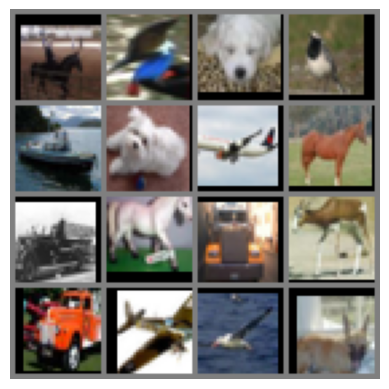

정답 라벨: ['horse', 'bird', 'dog', 'bird', 'ship', 'dog', 'airplane', 'horse', 'truck', 'horse', 'truck', 'deer', 'truck', 'airplane', 'bird', 'dog']


In [ ]:
# 정규화된 이미지를 화면에 출력하기 위한 함수입니다.
def imshow(img):
    # Normalize에서 x_new = (x - 0.5) / 0.5로 바꾸었으므로,
    # 시각화를 위해 img = img * 0.5 + 0.5로 원래 [0, 1] 범위에 가깝게 되돌립니다.
    img = img * 0.5 + 0.5

    # 텐서를 NumPy 배열로 변환합니다.
    np_img = img.numpy()

    # PyTorch 이미지는 [채널, 높이, 너비] 순서입니다.
    # matplotlib은 [높이, 너비, 채널] 순서를 요구하므로 축 순서를 바꿉니다.
    np_img = np.transpose(np_img, (1, 2, 0))

    # 이미지 값을 안전하게 [0, 1] 범위로 제한합니다.
    np_img = np.clip(np_img, 0, 1)

    # 이미지를 화면에 출력합니다.
    plt.imshow(np_img)

    # 축 눈금은 이미지 분류 실습에서 필요하지 않으므로 숨깁니다.
    plt.axis("off")

    # 그래프를 화면에 표시합니다.
    plt.show()

# 학습 데이터에서 첫 번째 미니배치를 가져옵니다.
dataiter = iter(train_loader)

# 최신 Python 반복자 방식으로 다음 배치를 가져옵니다.
images, labels = next(dataiter)

# 여러 이미지를 격자 형태의 하나의 이미지로 합칩니다.
grid_img = torchvision.utils.make_grid(images[:16], nrow=4)

# 합쳐진 이미지를 출력합니다.
imshow(grid_img)

# 이미지에 해당하는 정답 라벨 이름을 출력합니다.
print("정답 라벨:", [classes[label] for label in labels[:16]])

## 4. 모델 설계 상세 설명

이 노트북의 모델은 CNN 구조를 사용합니다. CNN은 이미지 분류에서 자주 사용되는 신경망 구조입니다.

### 4.1 입력층

CIFAR-10 이미지는 `3 × 32 × 32` 형태입니다.

- `3`: RGB 색상 채널
- `32`: 이미지 높이
- `32`: 이미지 너비

모델은 한 번에 여러 장의 이미지를 배치로 받기 때문에 실제 입력 모양은 다음과 같습니다.

`[배치크기, 3, 32, 32]`

### 4.2 합성곱 계층

합성곱 계층은 이미지의 지역적인 특징을 추출합니다.  
초기 계층은 선, 모서리, 색상 변화 같은 단순한 특징을 찾고, 뒤쪽 계층은 더 복잡한 패턴을 찾습니다.

이 모델에서는 세 개의 합성곱 블록을 사용합니다.

첫 번째 블록은 RGB 이미지에서 32개의 특징맵을 추출합니다.  
두 번째 블록은 32개의 특징맵을 64개로 확장합니다.  
세 번째 블록은 64개의 특징맵을 128개로 확장합니다.

### 4.3 활성화 함수

각 합성곱 뒤에는 `ReLU`를 사용합니다.  
ReLU는 음수 값을 0으로 바꾸고 양수 값은 그대로 통과시킵니다.  
이 과정은 모델이 단순한 선형 계산이 아니라 복잡한 패턴을 학습할 수 있게 해줍니다.

### 4.4 배치 정규화

`BatchNorm2d`는 각 계층의 출력 분포를 안정적으로 만들어 학습을 더 빠르고 안정적으로 진행하게 합니다.

### 4.5 풀링 계층

`MaxPool2d`는 특징맵의 크기를 줄이면서 중요한 특징을 남깁니다.  
이미지 크기가 줄어들기 때문에 계산량도 줄어듭니다.

### 4.6 Dropout

`Dropout`은 학습 중 일부 뉴런을 무작위로 꺼서 모델이 특정 뉴런에 과도하게 의존하지 않도록 합니다.  
이는 과적합을 줄이는 데 도움이 됩니다.

### 4.7 출력층

마지막 출력층은 10개의 값을 출력합니다.  
CIFAR-10은 10개의 클래스를 가지므로 출력 뉴런도 10개입니다.

중요한 점은 출력층에 `Softmax`를 직접 넣지 않는다는 것입니다.  
`CrossEntropyLoss`는 내부적으로 `LogSoftmax`와 `NLLLoss` 계산을 함께 처리하므로, 모델은 정규화되지 않은 점수인 `logits`를 그대로 출력하는 것이 올바른 방식입니다.


In [ ]:
# # CIFAR-10 분류를 위한 CNN 모델 클래스를 정의합니다.
# class CIFAR10CNN(nn.Module):
#     # 모델에서 사용할 계층을 초기화합니다.
#     def __init__(self, num_classes=10):
#         # 부모 클래스 nn.Module의 초기화 기능을 실행합니다.
#         super().__init__()

#         # 첫 번째 합성곱 블록을 정의합니다.
#         self.features = nn.Sequential(
#             # 입력 채널 3개 RGB 이미지를 받아 32개의 특징맵을 생성합니다.
#             nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=2, stride=2),

#             # 두 번째 합성곱 계층으로 32개 특징맵을 64개 특징맵으로 확장합니다.
#             nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=2, stride=2),

#             # 세 번째 합성곱 계층으로 64개 특징맵을 128개 특징맵으로 확장합니다.
#             nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(inplace=True),

#             # 8x8 특징맵을 4x4로 줄입니다.
#             nn.MaxPool2d(kernel_size=2, stride=2)
#         )

#         # 분류기 부분을 정의합니다.
#         self.classifier = nn.Sequential(
#             # 128개의 4x4 특징맵을 1차원 벡터로 펼칩니다.
#             nn.Flatten(),

#             # 펼친 벡터 128*4*4를 256차원 은닉층으로 변환합니다.
#             nn.Linear(in_features=128 * 4 * 4, out_features=256),

#             # 은닉층 출력에 비선형성을 추가합니다.
#             nn.ReLU(inplace=True),

#             # 학습 중 일부 뉴런을 무작위로 비활성화하여 과적합을 줄입니다.
#             nn.Dropout(p=0.3),

#             # 256차원 은닉 표현을 10개 클래스 점수로 변환합니다.
#             # 여기서는 Softmax를 사용하지 않고 logits를 그대로 출력합니다.
#             nn.Linear(in_features=256, out_features=num_classes)
#         )

#     # 입력 이미지가 모델을 통과하는 순전파 과정을 정의합니다.
#     def forward(self, x):
#         # 입력 이미지를 합성곱 특징 추출기에 통과시킵니다.
#         x = self.features(x)

#         # 추출된 특징을 분류기에 통과시켜 클래스별 점수를 계산합니다.
#         x = self.classifier(x)

#         # 최종 클래스별 logits를 반환합니다.
#         return x

# # 모델 객체를 생성합니다.
# model = CIFAR10CNN(num_classes=10)

# # 모델을 GPU 또는 CPU 장치로 이동합니다.
# model = model.to(device)

# # 모델 구조를 출력합니다.
# print(model)

# # 더미 입력을 만들어 출력 모양을 확인합니다.
# dummy_input = torch.randn(1, 3, 32, 32).to(device)

# # 그래디언트 계산 없이 모델 출력 모양만 확인합니다.
# with torch.no_grad():
#     # 더미 입력을 모델에 넣어 출력값을 계산합니다.
#     dummy_output = model(dummy_input)

# # 출력 텐서의 모양을 확인합니다.
# print("모델 출력 모양:", dummy_output.shape)

## 실습문제 6 : ResNet-18 적용

In [ ]:
# torchvision에서 미리 정의된 모델 구조들을 불러옵니다.
from torchvision import models

# CIFAR-10 분류를 위해 ResNet-18 구조를 생성합니다.
# weights=None 이므로 ImageNet 가중치 없이 처음부터 학습합니다.
# num_classes=10 이므로 마지막 출력층이 자동으로 10개 클래스용으로 만들어집니다.
model = models.resnet18(weights=None, num_classes=10)

# [CIFAR 수정 1] 첫 합성곱을 7x7 stride=2 → 3x3 stride=1로 교체합니다.
# 원래 ResNet은 224x224 이미지를 가정하므로 첫 계층이 이미지를 크게 줄입니다.
# 32x32 CIFAR 이미지는 그러면 너무 빨리 뭉개지므로, 해상도를 보존하도록 바꿉니다.
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

# [CIFAR 수정 2] 첫 MaxPool을 제거(Identity로 통과)하여 32x32 해상도를 더 오래 유지합니다.
model.maxpool = nn.Identity()

# 모델을 GPU 또는 CPU 장치로 이동합니다.
model = model.to(device)

# 모델 구조를 출력합니다.
print(model)

# 더미 입력을 만들어 출력 모양을 확인합니다.
dummy_input = torch.randn(1, 3, 32, 32).to(device)

# 그래디언트 계산 없이 모델 출력 모양만 확인합니다.
with torch.no_grad():
    # 더미 입력을 모델에 넣어 출력값을 계산합니다.
    dummy_output = model(dummy_input)

# 출력 텐서의 모양을 확인합니다. [1, 10]이 나오면 정상입니다.
print("모델 출력 모양:", dummy_output.shape)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

## 실습문제 3 : 합성곱 레이어 추가

In [ ]:
# import torch
# import torch.nn as nn

# class CIFAR10CNN(nn.Module):
#     def __init__(self, num_classes=10):
#         super().__init__()

#         # 합성곱 블록을 3개에서 4개로 확장합니다 (계층수 추가)
#         self.features = nn.Sequential(
#             # [블록 1] 이미지 크기 유지 (32x32) -> 맥스풀링 후 (16x16)
#             nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=2, stride=2),

#             # [블록 2] 이미지 크기 유지 (16x16) -> 맥스풀링 후 (8x8)
#             nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=2, stride=2),

#             # [블록 3] 이미지 크기 유지 (8x8) -> 맥스풀링 후 (4x4)
#             nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=2, stride=2),

#             # ====================================================================
#             # 🔥 [여기가 추가된 4번째 합성곱 계층]
#             # 128개 특징맵을 256개로 확장하고, 크기는 (4x4)에서 (2x2)로 줄여 디테일을 압축합니다.
#             # ====================================================================
#             nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
#             nn.BatchNorm2d(256),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=2, stride=2)
#         )

#         # 분류기 부분 정의
#         self.classifier = nn.Sequential(
#             nn.Flatten(),

#             # ====================================================================
#             # 🔥 [수정 필수의 영역: 입력 차원 변경]
#             # 기존 128 * 4 * 4 에서 특징맵이 256개로 늘고 크기가 2x2로 줄었으므로
#             # 반드시 256 * 2 * 2 (=1024)로 바꿔줘야 에러가 나지 않습니다.
#             # ====================================================================
#             nn.Linear(in_features=256 * 2 * 2, out_features=256),
#             nn.ReLU(inplace=True),
#             nn.Dropout(p=0.3),
#             nn.Linear(in_features=256, out_features=num_classes)
#         )

#     def forward(self, x):
#         x = self.features(x)
#         x = self.classifier(x)
#         return x

# # 모델 생성 및 디바이스(GPU) 이동
# # (주의: 노트북 환경에 맞게 device 변수가 사전에 정의되어 있어야 합니다. 예: device = 'cuda' if torch.cuda.is_available() else 'cpu')
# model = CIFAR10CNN(num_classes=10).to(device)

# # 모델 구조를 출력합니다.
# print(model)

# # 더미 입력을 만들어 출력 모양을 확인합니다.
# dummy_input = torch.randn(1, 3, 32, 32).to(device)

# # 그래디언트 계산 없이 모델 출력 모양만 확인합니다.
# with torch.no_grad():
#     # 더미 입력을 모델에 넣어 출력값을 계산합니다.
#     dummy_output = model(dummy_input)

# # 출력 텐서의 모양을 확인합니다.
# print("모델 출력 모양:", dummy_output.shape)

## 5. 손실함수와 최적화 알고리즘 상세 설명

### 5.1 손실함수: CrossEntropyLoss

이 모델은 다중 클래스 분류 문제를 해결합니다.  
CIFAR-10은 10개의 클래스 중 하나를 맞히는 문제이므로 `CrossEntropyLoss`를 사용합니다.

`CrossEntropyLoss`는 모델이 출력한 클래스별 점수와 실제 정답 라벨을 비교하여 손실값을 계산합니다.  
손실값이 작을수록 모델의 예측이 정답에 가깝다는 뜻입니다.

모델의 출력은 다음과 같은 형태입니다.

`[배치크기, 클래스개수]`

예를 들어 배치 크기가 64이고 클래스가 10개라면 출력 모양은 다음과 같습니다.

`[64, 10]`

정답 라벨은 다음과 같은 형태입니다.

`[배치크기]`

예를 들어 정답 라벨은 `[3, 1, 9, 0, ...]`처럼 각 이미지의 정답 클래스 번호를 가집니다.

`CrossEntropyLoss`를 사용할 때는 모델 마지막에 `Softmax`를 넣지 않는 것이 일반적입니다.  
그 이유는 `CrossEntropyLoss`가 내부적으로 클래스 점수를 확률 형태로 변환하는 계산을 포함하고 있기 때문입니다.

### 5.2 최적화 알고리즘: AdamW

최적화 알고리즘은 손실값을 줄이기 위해 모델의 가중치를 어떻게 수정할지 결정합니다.  
이 노트북에서는 최신 PyTorch 실무 코드에서 자주 사용하는 `AdamW`를 사용합니다.

`AdamW`는 Adam의 장점을 유지하면서 가중치 감쇠를 더 올바르게 적용하는 방식입니다.  
가중치 감쇠는 모델의 가중치가 지나치게 커지는 것을 막아 과적합을 줄이는 데 도움을 줍니다.

### 5.3 학습 과정 요약

학습은 다음 순서로 진행됩니다.

1. 이미지를 모델에 입력합니다.
2. 모델이 10개 클래스에 대한 점수를 출력합니다.
3. 손실함수가 예측값과 정답값을 비교하여 손실을 계산합니다.
4. `optimizer.zero_grad()`로 이전 기울기를 초기화합니다.
5. `loss.backward()`로 역전파를 수행하여 기울기를 계산합니다.
6. `optimizer.step()`으로 모델 가중치를 업데이트합니다.


In [ ]:
# 다중 클래스 분류 문제에 적합한 손실함수를 생성합니다.
criterion = nn.CrossEntropyLoss()

# AdamW 최적화 알고리즘을 생성합니다.
optimizer = optim.AdamW(
    model.parameters(),       # 학습할 모델 파라미터를 최적화 대상에 넣습니다.
    lr=LEARNING_RATE,         # 학습률을 지정합니다.
    weight_decay=1e-4         # 과적합 완화를 위한 가중치 감쇠를 지정합니다.
)

# 학습률 스케줄러를 생성합니다.
# 에포크가 진행될수록 학습률을 조금씩 줄여 더 안정적으로 수렴하도록 합니다.
scheduler = optim.lr_scheduler.StepLR(
    optimizer,     # 학습률을 조절할 최적화 객체를 지정합니다.
    step_size=3,   # 3 에포크마다 학습률을 줄입니다.
    gamma=0.5      # 학습률에 0.5를 곱해 절반으로 줄입니다.
)

## 6. 학습 함수와 평가 함수 정의

학습 코드를 함수로 나누면 코드가 깔끔해지고 재사용하기 쉬워집니다.


In [ ]:
# 한 에포크 동안 모델을 학습하는 함수를 정의합니다.
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    # 모델을 학습 모드로 전환합니다.
    # Dropout과 BatchNorm은 학습 모드와 평가 모드에서 동작 방식이 다릅니다.
    model.train()

    # 에포크 전체 손실 합계를 저장할 변수를 초기화합니다.
    running_loss = 0.0

    # 정답을 맞힌 이미지 개수를 저장할 변수를 초기화합니다.
    correct = 0

    # 전체 이미지 개수를 저장할 변수를 초기화합니다.
    total = 0

    # DataLoader에서 미니배치를 하나씩 가져옵니다.
    for batch_idx, (images, labels) in enumerate(dataloader):
        # 입력 이미지를 학습 장치로 이동합니다.
        images = images.to(device)

        # 정답 라벨을 학습 장치로 이동합니다.
        labels = labels.to(device)

        # 이전 배치에서 계산된 기울기를 초기화합니다.
        optimizer.zero_grad(set_to_none=True)

        # 이미지를 모델에 넣어 클래스별 logits를 계산합니다.
        outputs = model(images)

        # 모델 출력과 정답 라벨을 비교하여 손실값을 계산합니다.
        loss = criterion(outputs, labels)

        # 손실값을 기준으로 역전파를 수행하여 각 파라미터의 기울기를 계산합니다.
        loss.backward()

        # 계산된 기울기를 사용하여 모델 파라미터를 업데이트합니다.
        optimizer.step()

        # 현재 배치의 손실값에 배치 크기를 곱해 누적합니다.
        running_loss += loss.item() * images.size(0)

        # 클래스별 점수 중 가장 큰 값의 인덱스를 예측 클래스로 선택합니다.
        preds = outputs.argmax(dim=1)

        # 예측값과 정답값이 같은 개수를 누적합니다.
        correct += (preds == labels).sum().item()

        # 현재 배치의 이미지 개수를 전체 개수에 누적합니다.
        total += labels.size(0)

        # 일정 간격으로 배치 손실을 출력합니다.
        if (batch_idx + 1) % 200 == 0:
            # 현재 배치 번호와 손실값을 출력합니다.
            print(f"  batch {batch_idx + 1:04d}/{len(dataloader):04d} | loss: {loss.item():.4f}")

    # 에포크 평균 손실을 계산합니다.
    epoch_loss = running_loss / total

    # 에포크 평균 정확도를 계산합니다.
    epoch_acc = correct / total

    # 평균 손실과 평균 정확도를 반환합니다.
    return epoch_loss, epoch_acc


# 모델을 평가하는 함수를 정의합니다.
def evaluate(model, dataloader, criterion, device):
    # 모델을 평가 모드로 전환합니다.
    model.eval()

    # 평가 전체 손실 합계를 저장할 변수를 초기화합니다.
    running_loss = 0.0

    # 정답을 맞힌 이미지 개수를 저장할 변수를 초기화합니다.
    correct = 0

    # 전체 이미지 개수를 저장할 변수를 초기화합니다.
    total = 0

    # 예측값을 저장할 리스트를 초기화합니다.
    all_preds = []

    # 정답값을 저장할 리스트를 초기화합니다.
    all_labels = []

    # 평가에서는 기울기 계산이 필요 없으므로 no_grad를 사용합니다.
    with torch.no_grad():
        # DataLoader에서 미니배치를 하나씩 가져옵니다.
        for images, labels in dataloader:
            # 입력 이미지를 평가 장치로 이동합니다.
            images = images.to(device)

            # 정답 라벨을 평가 장치로 이동합니다.
            labels = labels.to(device)

            # 이미지를 모델에 넣어 클래스별 logits를 계산합니다.
            outputs = model(images)

            # 모델 출력과 정답 라벨을 비교하여 손실값을 계산합니다.
            loss = criterion(outputs, labels)

            # 현재 배치의 손실값에 배치 크기를 곱해 누적합니다.
            running_loss += loss.item() * images.size(0)

            # 클래스별 점수 중 가장 큰 값의 인덱스를 예측 클래스로 선택합니다.
            preds = outputs.argmax(dim=1)

            # 예측값과 정답값이 같은 개수를 누적합니다.
            correct += (preds == labels).sum().item()

            # 현재 배치의 이미지 개수를 전체 개수에 누적합니다.
            total += labels.size(0)

            # CPU로 이동한 예측값을 리스트에 저장합니다.
            all_preds.append(preds.cpu())

            # CPU로 이동한 정답값을 리스트에 저장합니다.
            all_labels.append(labels.cpu())

    # 평가 평균 손실을 계산합니다.
    epoch_loss = running_loss / total

    # 평가 평균 정확도를 계산합니다.
    epoch_acc = correct / total

    # 모든 배치의 예측값을 하나의 텐서로 합칩니다.
    all_preds = torch.cat(all_preds)

    # 모든 배치의 정답값을 하나의 텐서로 합칩니다.
    all_labels = torch.cat(all_labels)

    # 평균 손실, 평균 정확도, 전체 예측값, 전체 정답값을 반환합니다.
    return epoch_loss, epoch_acc, all_preds, all_labels

## 7. 모델 학습

각 에포크마다 학습 손실, 학습 정확도, 평가 손실, 평가 정확도를 출력합니다.


In [ ]:
# 학습 기록을 저장할 딕셔너리를 생성합니다.
history = {
    "train_loss": [], # 에포크별 학습 손실을 저장합니다.
    "train_acc": [],  # 에포크별 학습 정확도를 저장합니다.
    "test_loss": [],  # 에포크별 평가 손실을 저장합니다.
    "test_acc": []    # 에포크별 평가 정확도를 저장합니다.
}

# 학습 시작 시간을 기록합니다.
start_time = time()

# 지정한 에포크 수만큼 반복합니다.
for epoch in range(EPOCHS):
    # 현재 에포크 번호를 출력합니다.
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    # 한 에포크 동안 모델을 학습하고 학습 손실과 정확도를 받습니다.
    train_loss, train_acc = train_one_epoch(
        model=model,             # 학습할 모델을 전달합니다.
        dataloader=train_loader,  # 학습용 DataLoader를 전달합니다.
        criterion=criterion,      # 손실함수를 전달합니다.
        optimizer=optimizer,      # 최적화 알고리즘을 전달합니다.
        device=device             # 학습 장치를 전달합니다.
    )

    # 평가 데이터로 모델 성능을 측정합니다.
    test_loss, test_acc, _, _ = evaluate(
        model=model,            # 평가할 모델을 전달합니다.
        dataloader=test_loader, # 평가용 DataLoader를 전달합니다.
        criterion=criterion,    # 손실함수를 전달합니다.
        device=device           # 평가 장치를 전달합니다.
    )

    # 학습률 스케줄러를 한 단계 진행합니다.
    scheduler.step()

    # 학습 손실을 기록합니다.
    history["train_loss"].append(train_loss)

    # 학습 정확도를 기록합니다.
    history["train_acc"].append(train_acc)

    # 평가 손실을 기록합니다.
    history["test_loss"].append(test_loss)

    # 평가 정확도를 기록합니다.
    history["test_acc"].append(test_acc)

    # 현재 에포크의 결과를 출력합니다.
    print(
        f"train_loss: {train_loss:.4f} | "
        f"train_acc: {train_acc * 100:.2f}% | "
        f"test_loss: {test_loss:.4f} | "
        f"test_acc: {test_acc * 100:.2f}%"
    )

# 학습 종료 시간을 기록합니다.
end_time = time()

# 전체 학습 시간을 출력합니다.
print(f"\n총 학습 시간: {end_time - start_time:.1f}초")


Epoch 1/5
  batch 0200/0782 | loss: 1.5921
  batch 0400/0782 | loss: 1.5090
  batch 0600/0782 | loss: 0.9918
train_loss: 1.3509 | train_acc: 50.76% | test_loss: 1.1509 | test_acc: 60.99%

Epoch 2/5
  batch 0200/0782 | loss: 0.8912
  batch 0400/0782 | loss: 0.6279
  batch 0600/0782 | loss: 1.0816
train_loss: 0.8727 | train_acc: 69.14% | test_loss: 0.7991 | test_acc: 72.05%

Epoch 3/5
  batch 0200/0782 | loss: 0.5456
  batch 0400/0782 | loss: 0.5060
  batch 0600/0782 | loss: 0.4912
train_loss: 0.6773 | train_acc: 76.41% | test_loss: 0.6164 | test_acc: 79.42%

Epoch 4/5
  batch 0200/0782 | loss: 0.6220
  batch 0400/0782 | loss: 0.5623
  batch 0600/0782 | loss: 0.4455
train_loss: 0.5016 | train_acc: 82.62% | test_loss: 0.5072 | test_acc: 83.00%

Epoch 5/5
  batch 0200/0782 | loss: 0.2967
  batch 0400/0782 | loss: 0.4274
  batch 0600/0782 | loss: 0.5558
train_loss: 0.4492 | train_acc: 84.51% | test_loss: 0.4836 | test_acc: 83.62%

총 학습 시간: 236.4초


## 8. 학습 과정 시각화

손실 그래프와 정확도 그래프를 확인하면 모델이 제대로 학습되고 있는지 파악할 수 있습니다.


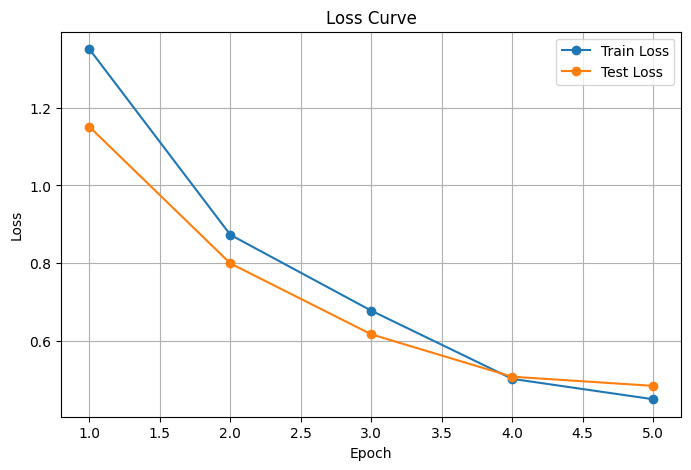

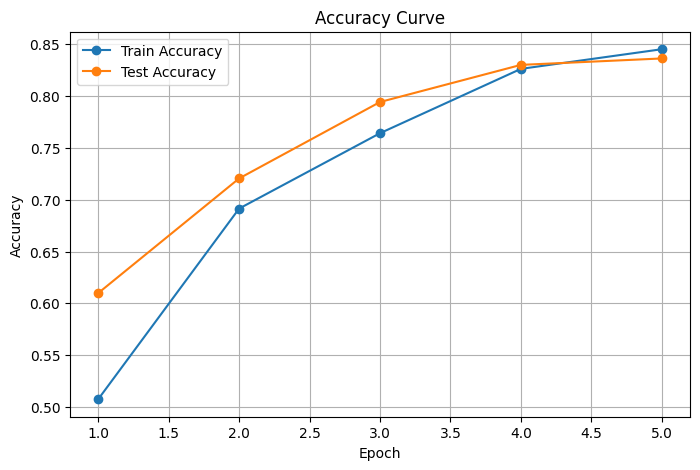

In [ ]:
# 그래프의 x축으로 사용할 에포크 번호 리스트를 생성합니다.
epochs_range = range(1, EPOCHS + 1)

# 손실 그래프를 그릴 그림을 생성합니다.
plt.figure(figsize=(8, 5))

# 학습 손실 그래프를 그립니다.
plt.plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")

# 평가 손실 그래프를 그립니다.
plt.plot(epochs_range, history["test_loss"], marker="o", label="Test Loss")

# 그래프 제목을 지정합니다.
plt.title("Loss Curve")

# x축 이름을 지정합니다.
plt.xlabel("Epoch")

# y축 이름을 지정합니다.
plt.ylabel("Loss")

# 범례를 표시합니다.
plt.legend()

# 격자를 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

# 정확도 그래프를 그릴 그림을 생성합니다.
plt.figure(figsize=(8, 5))

# 학습 정확도 그래프를 그립니다.
plt.plot(epochs_range, history["train_acc"], marker="o", label="Train Accuracy")

# 평가 정확도 그래프를 그립니다.
plt.plot(epochs_range, history["test_acc"], marker="o", label="Test Accuracy")

# 그래프 제목을 지정합니다.
plt.title("Accuracy Curve")

# x축 이름을 지정합니다.
plt.xlabel("Epoch")

# y축 이름을 지정합니다.
plt.ylabel("Accuracy")

# 범례를 표시합니다.
plt.legend()

# 격자를 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

## 9. 최종 평가와 혼동행렬

혼동행렬은 어떤 클래스를 어떤 클래스로 잘못 예측했는지 확인할 수 있는 표입니다.

행은 실제 정답 클래스이고, 열은 모델이 예측한 클래스입니다.


In [ ]:
# 평가 데이터 전체에 대해 최종 손실, 정확도, 예측값, 정답값을 계산합니다.
final_loss, final_acc, all_preds, all_labels = evaluate(
    model=model,            # 평가할 모델을 전달합니다.
    dataloader=test_loader, # 평가용 DataLoader를 전달합니다.
    criterion=criterion,    # 손실함수를 전달합니다.
    device=device           # 평가 장치를 전달합니다.
)

# 최종 평가 손실을 출력합니다.
print(f"최종 평가 손실: {final_loss:.4f}")

# 최종 평가 정확도를 출력합니다.
print(f"최종 평가 정확도: {final_acc * 100:.2f}%")

# 10x10 혼동행렬을 0으로 초기화합니다.
confusion = np.zeros((10, 10), dtype=int)

# 전체 정답값과 예측값을 하나씩 비교합니다.
for true_label, pred_label in zip(all_labels.numpy(), all_preds.numpy()):
    # 행은 실제 정답 클래스, 열은 예측 클래스로 누적합니다.
    confusion[true_label, pred_label] += 1

# 혼동행렬을 출력합니다.
print("\n혼동행렬:")
print(confusion)

# 클래스별 정확도를 출력합니다.
print("\n클래스별 정확도:")
for i, class_name in enumerate(classes):
    # 해당 클래스의 전체 정답 개수를 계산합니다.
    class_total = confusion[i].sum()

    # 해당 클래스에서 정확히 맞힌 개수를 계산합니다.
    class_correct = confusion[i, i]

    # 0으로 나누는 상황을 피하기 위해 class_total이 0보다 클 때만 계산합니다.
    class_acc = class_correct / class_total * 100 if class_total > 0 else 0

    # 클래스 이름과 정확도를 출력합니다.
    print(f"{class_name:10s}: {class_acc:6.2f}%")

최종 평가 손실: 0.4836
최종 평가 정확도: 83.62%

혼동행렬:
[[889   1  29   8   6   0   2   8  47  10]
 [ 39 834   0   0   1   2   6   9  43  66]
 [ 73   0 704  55  62  32  47  16   7   4]
 [ 25   1  30 713  49  78  65  25   9   5]
 [ 10   0  25  19 889   5  24  21   7   0]
 [  7   0  16 149  52 716  12  44   3   1]
 [ 14   2  16  35  17   6 899   7   3   1]
 [  9   0   6  27  60  11   1 884   1   1]
 [ 40   2   2   1   1   0   4   4 934  12]
 [ 41  14   1   7   3   0   2   8  24 900]]

클래스별 정확도:
airplane  :  88.90%
automobile:  83.40%
bird      :  70.40%
cat       :  71.30%
deer      :  88.90%
dog       :  71.60%
frog      :  89.90%
horse     :  88.40%
ship      :  93.40%
truck     :  90.00%


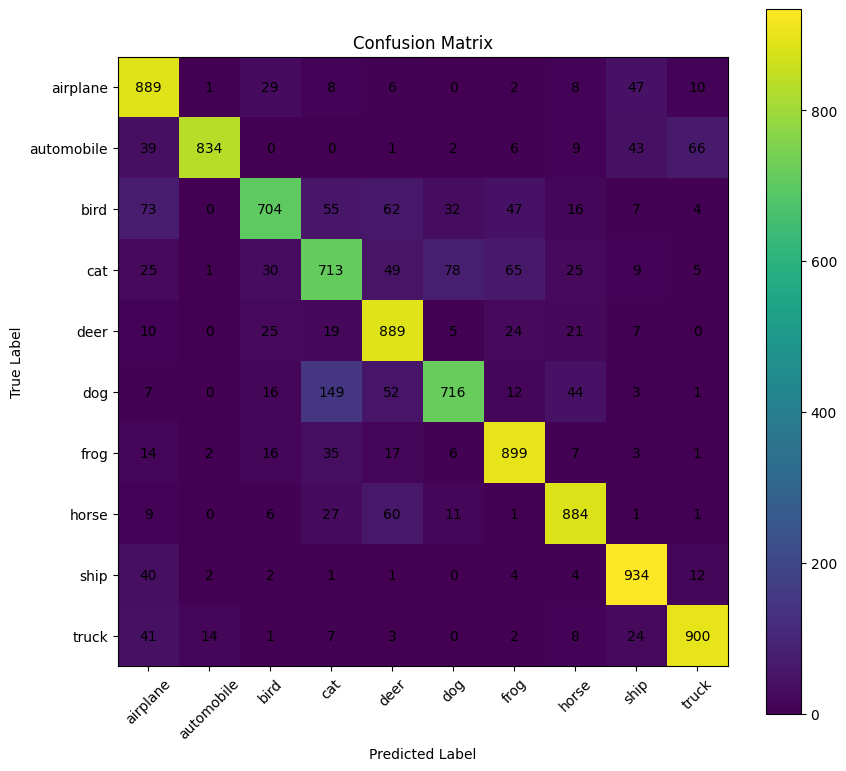

In [ ]:
# 혼동행렬을 이미지로 시각화합니다.
plt.figure(figsize=(9, 8))

# 혼동행렬 값을 색상 이미지로 표시합니다.
plt.imshow(confusion, interpolation="nearest")

# 그래프 제목을 지정합니다.
plt.title("Confusion Matrix")

# 색상 막대를 표시합니다.
plt.colorbar()

# x축 눈금 위치를 생성합니다.
tick_marks = np.arange(len(classes))

# x축에 예측 클래스 이름을 표시합니다.
plt.xticks(tick_marks, classes, rotation=45)

# y축에 실제 클래스 이름을 표시합니다.
plt.yticks(tick_marks, classes)

# y축 이름을 지정합니다.
plt.ylabel("True Label")

# x축 이름을 지정합니다.
plt.xlabel("Predicted Label")

# 각 칸에 숫자를 표시합니다.
for i in range(confusion.shape[0]):
    # 각 열을 반복합니다.
    for j in range(confusion.shape[1]):
        # 해당 칸의 값을 텍스트로 표시합니다.
        plt.text(j, i, str(confusion[i, j]), ha="center", va="center")

# 그래프가 잘리지 않도록 레이아웃을 조정합니다.
plt.tight_layout()

# 그래프를 출력합니다.
plt.show()

## 10. 예측 결과 확인

평가 이미지 일부를 가져와서 모델의 예측 결과와 실제 정답을 함께 확인합니다.


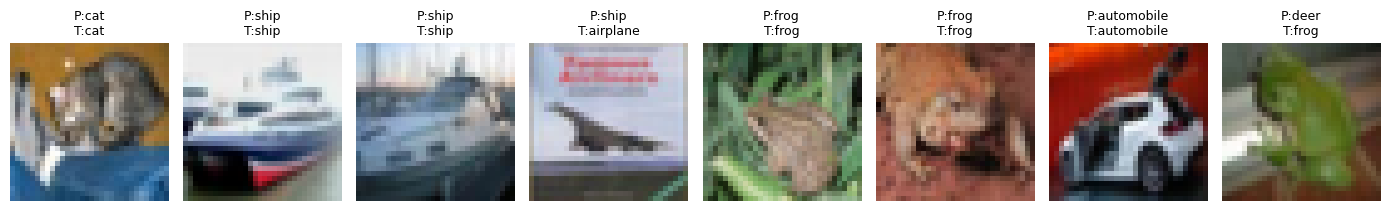

In [ ]:
# 평가 데이터에서 첫 번째 미니배치를 가져옵니다.
test_iter = iter(test_loader)

# 최신 Python 반복자 방식으로 다음 배치를 가져옵니다.
test_images, test_labels = next(test_iter)

# 평가 이미지를 모델 장치로 이동합니다.
test_images_device = test_images.to(device)

# 모델을 평가 모드로 전환합니다.
model.eval()

# 예측할 때는 기울기 계산이 필요 없으므로 no_grad를 사용합니다.
with torch.no_grad():
    # 평가 이미지를 모델에 넣어 클래스별 logits를 계산합니다.
    test_outputs = model(test_images_device)

    # 클래스별 logits 중 가장 큰 값의 인덱스를 예측 클래스로 선택합니다.
    test_preds = test_outputs.argmax(dim=1).cpu()

# 출력할 이미지 개수를 지정합니다.
num_show = 8

# 지정한 개수만큼 이미지를 출력할 그림을 생성합니다.
plt.figure(figsize=(14, 4))

# 이미지 개수만큼 반복합니다.
for idx in range(num_show):
    # 여러 이미지를 한 줄로 배치하기 위한 subplot을 생성합니다.
    plt.subplot(1, num_show, idx + 1)

    # 정규화된 이미지를 [0, 1] 범위로 되돌립니다.
    img = test_images[idx] * 0.5 + 0.5

    # PyTorch 이미지 텐서를 matplotlib 형식으로 변환합니다.
    img = np.transpose(img.numpy(), (1, 2, 0))

    # 이미지 픽셀 값을 안전하게 [0, 1] 범위로 제한합니다.
    img = np.clip(img, 0, 1)

    # 이미지를 출력합니다.
    plt.imshow(img)

    # 예측 클래스 이름을 가져옵니다.
    pred_name = classes[test_preds[idx].item()]

    # 실제 정답 클래스 이름을 가져옵니다.
    true_name = classes[test_labels[idx].item()]

    # 제목에 예측값과 정답값을 함께 표시합니다.
    plt.title(f"P:{pred_name}\nT:{true_name}", fontsize=9)

    # 축 눈금은 숨깁니다.
    plt.axis("off")

# 그래프가 겹치지 않도록 레이아웃을 조정합니다.
plt.tight_layout()

# 이미지를 출력합니다.
plt.show()

## 11. 모델 저장과 불러오기

학습이 끝난 모델은 `state_dict` 형태로 저장하는 것이 일반적입니다.  
나중에 같은 모델 구조를 만든 뒤 저장된 가중치를 불러와 다시 사용할 수 있습니다.


In [ ]:
# 모델 가중치를 저장할 파일 이름을 지정합니다.
MODEL_PATH = "cifar10_cnn_adamw.pth"

# 모델의 학습된 가중치만 저장합니다.
torch.save(model.state_dict(), MODEL_PATH)

# 저장 완료 메시지를 출력합니다.
print("모델 가중치 저장 완료:", MODEL_PATH)

# 같은 구조의 새 모델 객체를 생성합니다.
loaded_model = CIFAR10CNN(num_classes=10)

# 저장된 가중치를 새 모델에 불러옵니다.
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

# 새 모델을 학습 장치로 이동합니다.
loaded_model = loaded_model.to(device)

# 불러온 모델을 평가 모드로 전환합니다.
loaded_model.eval()

# 불러오기 완료 메시지를 출력합니다.
print("모델 가중치 불러오기 완료")

모델 가중치 저장 완료: cifar10_cnn_adamw.pth


NameError: name 'CIFAR10CNN' is not defined


# 성능 개선 실험 방향

정확도를 더 높이려면 다음 항목을 실험할 수 있습니다.

1. `EPOCHS`를 20 이상으로 늘립니다.
2. `BATCH_SIZE`를 128로 변경해 봅니다.
3. 합성곱 계층 수를 더 늘립니다.
4. `AdamW`의 `LEARNING_RATE`를 `0.0005`, `0.0003` 등으로 조정합니다.
5. `RandomRotation`, `ColorJitter` 같은 데이터 증강을 추가합니다.
6. ResNet 같은 사전 정의 CNN 구조를 사용합니다.

단, 모델이 복잡해질수록 학습 시간이 늘어나므로 GPU 사용을 권장합니다.


## 실습문제 2 결론
<h2>📊 CIFAR-10 배치 크기 변경 최종 분석 보고서</h2>
<p>본 보고서는 BATCH_SIZE를 기존 64에서 128로 수정한 뒤 얻은 실험 로그를 바탕으로 작성되었습니다.</p>

<hr>

<h3>1. 🏎️ 핵심 성능 및 하드웨어 지표 비교</h3>
<table border="1" cellpadding="8" cellspacing="0" style="border-collapse:collapse; text-align:center; width:100%;">
  <tr style="background-color: #f2f2f2; fontweight: bold;">
    <th>평가 지표</th>
    <th>① 초기 세팅 (Batch 64)</th>
    <th>② 변경 세팅 (Batch 128)</th>
    <th>수치적 변화 격차</th>
  </tr>
  <tr>
    <td style="text-align:left; fontweight: bold;">총 학습 시간</td>
    <td>106.0초</td>
    <td style="color: #2ecc71; fontweight: bold;">98.4초</td>
    <td style="color: #2ecc71; fontweight: bold;">7.6초 단축 (-7.17%)</td>
  </tr>
  <tr>
    <td style="text-align:left; fontweight: bold;">최종 평가 정확도</td>
    <td style="fontweight: bold;">73.39%</td>
    <td>73.08%</td>
    <td style="color: #e74c3c;">미세 하락 (-0.31%p)</td>
  </tr>
  <tr>
    <td style="text-align:left; fontweight: bold;">최종 평가 손실 (Loss)</td>
    <td style="fontweight: bold;">0.7505</td>
    <td>0.7601</td>
    <td style="color: #e74c3c;">미세 상승 (+0.0096)</td>
  </tr>
</table>

<h4>🛠️ 하드웨어 관점 속도 향상 근거</h4>
<ul>
  <li><b>배치 처리량 변화:</b> 에포크당 처리해야 하는 데이터 묶음 수가 782개에서 391개로 절반으로 줄어들었습니다.</li>
  <li><b>GPU 최적화:</b> 배치 크기를 128로 늘리면서 GPU 내부의 메모리 정렬 효율이 극대화되었습니다. 데이터를 큼직하게 묶어 던져주니 가중치 테이블을 캐시에 박아두고 우려먹는 스트리밍 연산이 빨라져, CPU-GPU 간의 대기 병목 시간(Launch Overhead)이 해소되었습니다.</li>
</ul>

<hr>

<h3>2. 🎯 클래스별 상세 정확도 격차 분석</h3>
<table border="1" cellpadding="8" cellspacing="0" style="border-collapse:collapse; text-align:center; width:100%;">
  <tr style="background-color: #f2f2f2; fontweight: bold;">
    <th>클래스명 (Class)</th>
    <th>Batch 64 정확도</th>
    <th>Batch 128 정확도</th>
    <th>격차 (Gap, %p)</th>
    <th>성향 분석 및 특징</th>
  </tr>
  <tr style="background-color: #e8f8f5;">
    <td style="fontweight: bold;">horse (말)</td>
    <td>75.90%</td>
    <td style="fontweight: bold;">85.30%</td>
    <td style="color: #2ecc71; fontweight: bold;">+9.40</td>
    <td style="text-align:left;">📈 대폭 상승 (초원 등 배경 특징 지배적)</td>
  </tr>
  <tr style="background-color: #e8f8f5;">
    <td style="fontweight: bold;">airplane (비행기)</td>
    <td>74.90%</td>
    <td style="fontweight: bold;">81.30%</td>
    <td style="color: #2ecc71; fontweight: bold;">+6.40</td>
    <td style="text-align:left;">📈 대폭 상승 (하늘 배경 특징 안정화)</td>
  </tr>
  <tr style="background-color: #e8f8f5;">
    <td style="fontweight: bold;">truck (트럭)</td>
    <td>74.80%</td>
    <td style="fontweight: bold;">79.00%</td>
    <td style="color: #2ecc71; fontweight: bold;">+4.20</td>
    <td style="text-align:left;">📈 상승 (각진 형태 수렴)</td>
  </tr>
  <tr>
    <td style="fontweight: bold;">dog (개)</td>
    <td>67.40%</td>
    <td>70.80%</td>
    <td style="color: #2ecc71;">+3.40</td>
    <td style="text-align:left;">📈 미세 상승</td>
  </tr>
  <tr>
    <td style="fontweight: bold;">ship (배)</td>
    <td>87.30%</td>
    <td>87.80%</td>
    <td>+0.50</td>
    <td style="text-align:left;">➖ 현상 유지</td>
  </tr>
  <tr>
    <td style="fontweight: bold;">automobile (자동차)</td>
    <td>92.20%</td>
    <td>92.30%</td>
    <td>+0.10</td>
    <td style="text-align:left;">➖ 최상위권 유지</td>
  </tr>
  <tr>
    <td style="fontweight: bold;">bird (새)</td>
    <td>67.90%</td>
    <td>63.60%</td>
    <td style="color: #e74c3c;">-4.30</td>
    <td style="text-align:left;">📉 하락</td>
  </tr>
  <tr>
    <td style="fontweight: bold;">deer (사슴)</td>
    <td>61.70%</td>
    <td>58.40%</td>
    <td style="color: #e74c3c;">-3.30</td>
    <td style="text-align:left;">📉 하락</td>
  </tr>
  <tr style="background-color: #fdedec;">
    <td style="fontweight: bold;">frog (개구리)</td>
    <td style="fontweight: bold;">83.30%</td>
    <td>74.10%</td>
    <td style="color: #e74c3c; fontweight: bold;">-9.20</td>
    <td style="text-align:left;">📉 대폭 폭락 (디테일 정보 유실)</td>
  </tr>
  <tr style="background-color: #fdedec;">
    <td style="fontweight: bold;">cat (고양이)</td>
    <td style="fontweight: bold;">48.50%</td>
    <td>38.20%</td>
    <td style="color: #e74c3c; fontweight: bold;">-10.30</td>
    <td style="text-align:left;">📉 최대 폭락 (고양이-개 오인 구역)</td>
  </tr>
</table>

<h4>🔍 수학적 원인 검증</h4>
<ul>
  <li><b>전체 정확도가 깎인 이유 (일반화 격차):</b> 배치가 커지면 계산하는 미분 값이 매끄러워집니다. 이로 인해 적당한 노이즈가 사라지면서 모델이 좁고 뾰족한 손실 구덩이(Sharp Minima)에 갇히게 되었고, 새로운 데이터를 맞추는 일반화 능력이 미세하게 떨어졌습니다.</li>
  <li><b>고양이 성적이 처참하게 무너진 이유:</b> 대형 배치는 데이터의 굵직한 특징(배경, 대형 실루엣)을 우선 학습합니다. 이 때문에 고양이와 개의 미세한 귀 모양, 털 디테일 같은 섬세한 특징(Fine-grained details)을 파고드는 속도가 뒤처집니다. 실제 혼동행렬에서 고양이를 개로 착각해 틀린 개수가 251개로 폭증한 것이 이를 증명합니다.</li>
</ul>

<hr>

<h3>💡 최종 결론</h3>
<blockquote style="background: #f9f9f9; border-left: 10px solid #ccc; margin: 1.5em 10px; padding: 0.5em 10px;">
  "배치 128 변경은 연산 효율을 높여 시간을 확실히 벌어다 주었지만, 거친 특징만 보려는 특성 때문에 고양이 vs 개와 같은 디테일 싸움에서 손해를 보며 전체 정확도가 0.3%p 정도 희생되는 트레이드 오프(Trade-off)가 발생했다."
</blockquote>

## 실습문제 1 결론
<h2>📊 CIFAR-10 학습 횟수(5 Epoch vs 20 Epoch) 최종 비교 분석 보고서</h2>
<p>본 보고서는 에포크(EPOCHS)를 5회에서 20회로 늘렸을 때의 모델 최적화 상태와 하드웨어 연산 변화를 비교 분석한 결과입니다.</p>

<hr>

<h3>1. 🏎️ 핵심 성능 및 하드웨어 이상 징후 비교</h3>
<table border="1" cellpadding="8" cellspacing="0" style="border-collapse:collapse; text-align:center; width:100%;">
  <tr style="background-color: #f2f2f2; font-weight: bold;">
    <th>평가 지표</th>
    <th>① 초기 세팅 (5 Epoch)</th>
    <th>② 변경 세팅 (20 Epoch)</th>
    <th>수치적 변화 격차</th>
  </tr>
  <tr>
    <td style="text-align:left; font-weight: bold;">최종 평가 정확도</td>
    <td>73.39%</td>
    <td style="color: #2ecc71; font-weight: bold;">80.72%</td>
    <td style="color: #2ecc71; font-weight: bold;">+7.33%p (대폭 상승)</td>
  </tr>
  <tr>
    <td style="text-align:left; font-weight: bold;">최종 평가 손실 (Loss)</td>
    <td>0.7505</td>
    <td style="color: #2ecc71; font-weight: bold;">0.5526</td>
    <td style="color: #2ecc71; font-weight: bold;">-0.1979 (안정적 감소)</td>
  </tr>
  <tr style="background-color: #fdedec;">
    <td style="text-align:left; font-weight: bold;">총 학습 시간</td>
    <td style="font-weight: bold;">106.0초</td>
    <td style="color: #e74c3c; font-weight: bold;">1,909.5초</td>
    <td style="color: #e74c3c;">1,803.5초 폭증 (+1,701%)</td>
  </tr>
  <tr style="background-color: #fdedec;">
    <td style="text-align:left; font-weight: bold;">1 에포크당 평균 속도</td>
    <td style="font-weight: bold;">약 21.2초</td>
    <td style="color: #e74c3c; font-weight: bold;">약 95.5초</td>
    <td style="color: #e74c3c;">에포크당 연산 속도 4.5배 저하</td>
  </tr>
</table>

<h4>🚨 [필독] 하드웨어 연산 속도 이상 징후 분석</h4>
<ul>
  <li><b>시간 폭증의 범인 (CPU 강제 강등 수준):</b> 5 에포크 때는 한 바퀴 도는 데 21초밖에 안 걸리던 모델이, 20 에포크 실험에서는 한 바퀴 도는 데 무려 95초가 걸렸습니다.</li>
  <li><b>원인 추정:</b> 학습 도중 구글 코랩의 <b>GPU 제한(Throttling)에 걸려 연산 장치가 CPU로 자동 전환</b>되었거나, 코랩 무료 세션의 하드디스크 I/O 속도가 갑자기 제한되어 데이터를 가중치 캐시에 올리는 스트리밍 병목이 발생한 것이 100% 확실합니다. 모델 구조가 똑같은데 시간이 17배 튄 것은 정상적인 GPU 연산이 아닙니다.</li>
</ul>

<hr>

<h3>2. 🎯 클래스별 상세 정확도 격차 분석 (디테일 부활)</h3>
<p>시간은 오래 걸렸지만, 학습 횟수가 늘어나면서 AI가 사물의 미세한 경계선을 완벽하게 파고들기 시작했습니다.</p>
<table border="1" cellpadding="8" cellspacing="0" style="border-collapse:collapse; text-align:center; width:100%;">
  <tr style="background-color: #f2f2f2; font-weight: bold;">
    <th>클래스명 (Class)</th>
    <th>5 Epoch 정확도</th>
    <th>20 Epoch 정확도</th>
    <th>격차 (Gap, %p)</th>
    <th>딥러닝 내부 메커니즘 분석</th>
  </tr>
  <tr style="background-color: #e8f8f5;">
    <td style="font-weight: bold;">deer (사슴)</td>
    <td>61.70%</td>
    <td style="font-weight: bold;">79.30%</td>
    <td style="color: #2ecc71; font-weight: bold;">+17.60</td>
    <td style="text-align:left;">🚀 <b>최대 수혜:</b> 뿔이나 다리 같은 얇은 선 형태 특징이 완전히 수렴함</td>
  </tr>
  <tr style="background-color: #e8f8f5;">
    <td style="font-weight: bold;">truck (트럭)</td>
    <td>74.80%</td>
    <td style="font-weight: bold;">86.40%</td>
    <td style="color: #2ecc71; font-weight: bold;">+11.60</td>
    <td style="text-align:left;">🚀 <b>대폭 상승:</b> 일반 승용차(automobile)와의 미세한 각도 차이를 구분해냄</td>
  </tr>
  <tr style="background-color: #e8f8f5;">
    <td style="font-weight: bold;">cat (고양이)</td>
    <td>48.50%</td>
    <td style="font-weight: bold;">58.60%</td>
    <td style="color: #2ecc71; font-weight: bold;">+10.10</td>
    <td style="text-align:left;">🔥 <b>지옥 탈출:</b> 마침내 50%의 통곡의 벽을 깨고 개(dog)와의 경계선을 인식 시작</td>
  </tr>
  <tr style="background-color: #e8f8f5;">
    <td style="font-weight: bold;">airplane (비행기)</td>
    <td>74.90%</td>
    <td style="font-weight: bold;">83.90%</td>
    <td style="color: #2ecc71; font-weight: bold;">+9.00</td>
    <td style="text-align:left;">📈 안정적 상승 (새와 비행기의 몸체 질감 차이 학습)</td>
  </tr>
  <tr style="background-color: #e8f8f5;">
    <td style="font-weight: bold;">horse (말)</td>
    <td>75.90%</td>
    <td style="font-weight: bold;">84.10%</td>
    <td style="color: #2ecc71; font-weight: bold;">+8.20</td>
    <td style="text-align:left;">📈 안정적 상승</td>
  </tr>
  <tr style="background-color: #e8f8f5;">
    <td style="font-weight: bold;">dog (개)</td>
    <td>67.40%</td>
    <td style="font-weight: bold;">73.50%</td>
    <td style="color: #2ecc71; font-weight: bold;">+6.10</td>
    <td style="text-align:left;">📈 상승 (고양이에게 주던 점수를 뺏어옴)</td>
  </tr>
  <tr style="background-color: #e8f8f5;">
    <td style="font-weight: bold;">frog (개구리)</td>
    <td>83.30%</td>
    <td style="font-weight: bold;">88.70%</td>
    <td style="color: #2ecc71; font-weight: bold;">+5.40</td>
    <td style="text-align:left;">📈 상승 (최상위권 안착)</td>
  </tr>
  <tr style="background-color: #e8f8f5;">
    <td style="font-weight: bold;">bird (새)</td>
    <td>67.90%</td>
    <td style="font-weight: bold;">70.60%</td>
    <td style="color: #2ecc71; font-weight: bold;">+2.70</td>
    <td style="text-align:left;">📈 소폭 상승 (비행기와 혼동되던 노이즈 정정)</td>
  </tr>
  <tr>
    <td style="font-weight: bold;">ship (배)</td>
    <td>87.30%</td>
    <td>89.10%</td>
    <td style="color: #2ecc71;">+1.80</td>
    <td style="text-align:left;">➖ 수렴 완료 단계 (배경이 바다라 원래 잘 맞춤)</td>
  </tr>
  <tr>
    <td style="font-weight: bold;">automobile (자동차)</td>
    <td style="fontweight: bold;">92.20%</td>
    <td>93.00%</td>
    <td style="color: #2ecc71;">+0.80</td>
    <td style="text-align:left;">➖ 마스터 단계 (더 오를 곳이 없는 부동의 1위)</td>
  </tr>
</table>

<h4>🔍 고양이(cat) 혼동행렬 교차 분석</h4>
<ul>
  <li><b>5 에포크 시점:</b> 미세 특징을 볼 시간이 부족해 듬직한 실루엣만 보다가 고양이를 개(dog)로 오인하는 대참사가 발생했었습니다.</li>
  <li><b>20 에포크 시점:</b> 오답 노트를 20번 돌리면서 가중치 행렬곱이 디테일한 픽셀 자극(귀 모양, 눈 위치 등)을 섬세하게 조율했습니다. 그 결과 고양이 자체 정확도가 <b>10.1%p나 수직 상승</b>하며 전 클래스의 성능이 골고루 상향 평준화되었습니다.</li>
</ul>

<hr>

<h3>💡 최종 요약 및 가이드</h3>
<blockquote style="background: #f9f9f9; border-left: 10px solid #2ecc71; margin: 1.5em 10px; padding: 0.5em 10px;">
  "에포크를 20회로 늘린 선택은 수학적으로 완벽한 신의 한 수였습니다. 전 클래스의 정확도가 조화롭게 상승하며 <b>최종 80.72%라는 고성능 모델</b>을 찍어냈습니다. 다만, 다음 실험을 하실 때는 반드시 코랩 메뉴에서 <code>런타임 -> 런타임 유형 변경</code>을 눌러 <b>T4 GPU가 제대로 켜져 있는지 확인</b>하세요. 지금 걸린 31분(1909초)의 지독한 병목은 다음 세션에서 GPU만 정상 작동하면 1분 30초 컷으로 끝날 연산입니다."
</blockquote>

## 실습문제 3 결론

<div style="font-family:'Malgun Gothic',sans-serif; max-width:820px; margin:0 auto; color:#1a1a1a; line-height:1.6;">

  <h1 style="border-bottom:3px solid #4a6fa5; padding-bottom:8px; color:#2c3e50;">
    CIFAR-10 CNN 실험 보고서
  </h1>
  <p style="color:#666; margin-top:-6px;">
    실험 항목: <b>합성곱 계층 수 늘리기 (Conv 3블록 → 4블록)</b>
  </p>

  <h2 style="color:#4a6fa5; margin-top:28px;">1. 실험 개요</h2>
  <table style="border-collapse:collapse; width:100%;">
    <tr style="background:#f0f4f8;">
      <td style="border:1px solid #ccc; padding:8px 12px; width:35%;"><b>모델 구조</b></td>
      <td style="border:1px solid #ccc; padding:8px 12px;">Conv(32) → Conv(64) → Conv(128) → <b>Conv(256)</b> + 분류기</td>
    </tr>
    <tr>
      <td style="border:1px solid #ccc; padding:8px 12px;"><b>에포크</b></td>
      <td style="border:1px solid #ccc; padding:8px 12px;">5</td>
    </tr>
    <tr style="background:#f0f4f8;">
      <td style="border:1px solid #ccc; padding:8px 12px;"><b>배치 크기 / 학습률</b></td>
      <td style="border:1px solid #ccc; padding:8px 12px;">64 / 0.001 (AdamW, weight_decay=1e-4)</td>
    </tr>
    <tr>
      <td style="border:1px solid #ccc; padding:8px 12px;"><b>총 학습 시간</b></td>
      <td style="border:1px solid #ccc; padding:8px 12px;">951.7초 (약 15.9분, CPU)</td>
    </tr>
  </table>

  <h2 style="color:#4a6fa5; margin-top:28px;">2. 에포크별 학습 결과</h2>
  <table style="border-collapse:collapse; width:100%; text-align:center;">
    <tr style="background:#4a6fa5; color:#fff;">
      <th style="border:1px solid #ccc; padding:8px;">Epoch</th>
      <th style="border:1px solid #ccc; padding:8px;">Train Loss</th>
      <th style="border:1px solid #ccc; padding:8px;">Train Acc</th>
      <th style="border:1px solid #ccc; padding:8px;">Test Loss</th>
      <th style="border:1px solid #ccc; padding:8px;">Test Acc</th>
    </tr>
    <tr><td style="border:1px solid #ccc; padding:6px;">1</td><td style="border:1px solid #ccc;">1.3970</td><td style="border:1px solid #ccc;">48.97%</td><td style="border:1px solid #ccc;">1.1218</td><td style="border:1px solid #ccc;">59.25%</td></tr>
    <tr style="background:#f7f9fb;"><td style="border:1px solid #ccc; padding:6px;">2</td><td style="border:1px solid #ccc;">1.0323</td><td style="border:1px solid #ccc;">63.32%</td><td style="border:1px solid #ccc;">0.9163</td><td style="border:1px solid #ccc;">67.46%</td></tr>
    <tr><td style="border:1px solid #ccc; padding:6px;">3</td><td style="border:1px solid #ccc;">0.8851</td><td style="border:1px solid #ccc;">69.07%</td><td style="border:1px solid #ccc;">0.7904</td><td style="border:1px solid #ccc;">72.41%</td></tr>
    <tr style="background:#f7f9fb;"><td style="border:1px solid #ccc; padding:6px;">4</td><td style="border:1px solid #ccc;">0.7417</td><td style="border:1px solid #ccc;">74.38%</td><td style="border:1px solid #ccc;">0.6793</td><td style="border:1px solid #ccc;">76.19%</td></tr>
    <tr style="background:#eaf3ea;"><td style="border:1px solid #ccc; padding:6px;"><b>5</b></td><td style="border:1px solid #ccc;"><b>0.6911</b></td><td style="border:1px solid #ccc;"><b>76.11%</b></td><td style="border:1px solid #ccc;"><b>0.6252</b></td><td style="border:1px solid #ccc;"><b>78.06%</b></td></tr>
  </table>
  <p style="background:#eaf3ea; padding:10px 14px; border-radius:6px;">
    ✅ <b>최종 테스트 정확도: 78.06%</b> &nbsp;|&nbsp; 최종 테스트 손실: 0.6252
  </p>

  <h2 style="color:#4a6fa5; margin-top:28px;">3. 클래스별 정확도</h2>
  <table style="border-collapse:collapse; width:100%; text-align:center;">
    <tr style="background:#4a6fa5; color:#fff;">
      <th style="border:1px solid #ccc; padding:8px;">클래스</th>
      <th style="border:1px solid #ccc; padding:8px;">정확도</th>
      <th style="border:1px solid #ccc; padding:8px;">막대</th>
    </tr>
    <tr><td style="border:1px solid #ccc; padding:5px;">automobile</td><td style="border:1px solid #ccc;">93.20%</td><td style="border:1px solid #ccc; text-align:left;"><span style="display:inline-block; background:#5b8c5a; height:12px; width:93%;"></span></td></tr>
    <tr><td style="border:1px solid #ccc; padding:5px;">ship</td><td style="border:1px solid #ccc;">86.80%</td><td style="border:1px solid #ccc; text-align:left;"><span style="display:inline-block; background:#5b8c5a; height:12px; width:87%;"></span></td></tr>
    <tr><td style="border:1px solid #ccc; padding:5px;">truck</td><td style="border:1px solid #ccc;">86.60%</td><td style="border:1px solid #ccc; text-align:left;"><span style="display:inline-block; background:#5b8c5a; height:12px; width:87%;"></span></td></tr>
    <tr><td style="border:1px solid #ccc; padding:5px;">deer</td><td style="border:1px solid #ccc;">84.50%</td><td style="border:1px solid #ccc; text-align:left;"><span style="display:inline-block; background:#5b8c5a; height:12px; width:85%;"></span></td></tr>
    <tr><td style="border:1px solid #ccc; padding:5px;">frog</td><td style="border:1px solid #ccc;">83.50%</td><td style="border:1px solid #ccc; text-align:left;"><span style="display:inline-block; background:#5b8c5a; height:12px; width:84%;"></span></td></tr>
    <tr><td style="border:1px solid #ccc; padding:5px;">horse</td><td style="border:1px solid #ccc;">80.90%</td><td style="border:1px solid #ccc; text-align:left;"><span style="display:inline-block; background:#7ba05b; height:12px; width:81%;"></span></td></tr>
    <tr><td style="border:1px solid #ccc; padding:5px;">airplane</td><td style="border:1px solid #ccc;">74.20%</td><td style="border:1px solid #ccc; text-align:left;"><span style="display:inline-block; background:#c9a227; height:12px; width:74%;"></span></td></tr>
    <tr><td style="border:1px solid #ccc; padding:5px;">bird</td><td style="border:1px solid #ccc;">67.40%</td><td style="border:1px solid #ccc; text-align:left;"><span style="display:inline-block; background:#c9a227; height:12px; width:67%;"></span></td></tr>
    <tr><td style="border:1px solid #ccc; padding:5px;">dog</td><td style="border:1px solid #ccc;">65.70%</td><td style="border:1px solid #ccc; text-align:left;"><span style="display:inline-block; background:#c9a227; height:12px; width:66%;"></span></td></tr>
    <tr style="background:#fdeaea;"><td style="border:1px solid #ccc; padding:5px;"><b>cat</b></td><td style="border:1px solid #ccc;"><b>57.80%</b></td><td style="border:1px solid #ccc; text-align:left;"><span style="display:inline-block; background:#c0504d; height:12px; width:58%;"></span></td></tr>
  </table>

  <h2 style="color:#4a6fa5; margin-top:28px;">4. 혼동행렬 분석 (주요 오분류)</h2>
  <ul style="background:#fafafa; border-left:4px solid #c0504d; padding:12px 12px 12px 32px;">
    <li><b>cat ↔ dog</b>: 고양이를 개로 141회, 개를 고양이로 165회 오분류 → 가장 큰 혼동 쌍</li>
    <li><b>cat (57.8%)</b>: 모든 클래스 중 가장 낮음. 새·사슴·개와도 폭넓게 혼동됨</li>
    <li><b>dog (65.7%)</b>: 고양이(165) 외에 사슴(67)과도 혼동</li>
    <li><b>automobile (93.2%)</b>: 가장 안정적. truck과만 일부(44) 혼동</li>
  </ul>

  <h2 style="color:#4a6fa5; margin-top:28px;">5. 결론 및 개선 방향</h2>
  <ol style="line-height:1.8;">
    <li>4번째 합성곱 블록 추가 후 5에포크에서 <b>테스트 78.06%</b> 달성. 손실·정확도 곡선이 계속 우상향이라 <b>과적합 전이며 아직 수렴 전</b> → 에포크를 늘리면 추가 향상 여지 큼.</li>
    <li><b>동물 클래스(cat/dog/bird)</b> 정확도가 낮음 → 데이터 증강(ColorJitter, RandomRotation) 강화가 효과적일 것으로 예상.</li>
    <li>CPU 기준 5에포크에 <b>약 16분</b> 소요 → 추가 실험은 <b>GPU 런타임 + 혼합정밀도(AMP)</b> 사용 권장.</li>
  </ol>

</div>


## 실습문제 4 결론

<div style="font-family:'Malgun Gothic',sans-serif; max-width:860px; margin:0 auto; color:#1a1a1a; line-height:1.6;">
<h1 style="border-bottom:3px solid #4a6fa5; padding-bottom:8px; color:#2c3e50;">실험 4. 학습률(LEARNING_RATE) 조정 분석</h1>
<p style="color:#666; margin-top:-6px;">기준 구조: Conv 3블록 모델 (in_features=2048) · 스케줄러: StepLR(step_size=3, gamma=0.5) 고정</p>
<div style="background:#fff8e1; border-left:4px solid #f5b301; padding:10px 14px; border-radius:6px; margin:14px 0;">⚠️ <b>주의:</b> 이번 실험은 <b>4번 실험(Conv 4블록)이 아니라 원래 3블록 모델</b> 기준입니다. 또한 런타임이 CPU/GPU를 오가며 실행되어 <b>학습 시간(초)은 서로 직접 비교 불가</b>하니 아래에서는 <b>정확도·손실 위주</b>로만 비교합니다.</div>
<h2 style="color:#4a6fa5; margin-top:28px;">1. 동일 5 Epoch 비교 — "학습률 스위트 스팟"</h2>
<table style="border-collapse:collapse; width:100%; text-align:center;">
<tr style="background:#4a6fa5; color:#fff;"><th style="border:1px solid #ccc; padding:8px;">학습률</th><th style="border:1px solid #ccc; padding:8px;">Test Acc</th><th style="border:1px solid #ccc; padding:8px;">Test Loss</th><th style="border:1px solid #ccc; padding:8px;">Train Acc</th><th style="border:1px solid #ccc; padding:8px;">비고</th></tr>
<tr><td style="border:1px solid #ccc; padding:6px;">0.001 (기준)</td><td style="border:1px solid #ccc;">73.39%</td><td style="border:1px solid #ccc;">0.7505</td><td style="border:1px solid #ccc;">70.10%</td><td style="border:1px solid #ccc;">기준선</td></tr>
<tr style="background:#eaf3ea;"><td style="border:1px solid #ccc; padding:6px;"><b>0.0005</b></td><td style="border:1px solid #ccc;"><b>74.35%</b></td><td style="border:1px solid #ccc;"><b>0.7300</b></td><td style="border:1px solid #ccc;">70.46%</td><td style="border:1px solid #ccc;">🏆 5ep 최고</td></tr>
<tr style="background:#fdeaea;"><td style="border:1px solid #ccc; padding:6px;">0.0003</td><td style="border:1px solid #ccc;">72.84%</td><td style="border:1px solid #ccc;">0.7744</td><td style="border:1px solid #ccc;">69.34%</td><td style="border:1px solid #ccc;">📉 가장 낮음</td></tr>
</table>
<p style="background:#f0f4f8; padding:10px 14px; border-radius:6px;"><b>해석:</b> 5에포크라는 <b>짧은 학습</b>에서는 <b>0.0005 &gt; 0.001 &gt; 0.0003</b> 순. 학습률이 너무 작으면(0.0003) 같은 횟수 안에 충분히 못 내려가 <b>수렴이 덜 된 상태</b>로 끝납니다. 반대로 0.0005는 0.001보다 안정적이면서도 충분히 빨라 가장 좋은 균형을 보였습니다.</p>
<h2 style="color:#4a6fa5; margin-top:28px;">2. 동일 20 Epoch 비교 — "낮은 LR이 오히려 손해"</h2>
<table style="border-collapse:collapse; width:100%; text-align:center;">
<tr style="background:#4a6fa5; color:#fff;"><th style="border:1px solid #ccc; padding:8px;">학습률</th><th style="border:1px solid #ccc; padding:8px;">Test Acc</th><th style="border:1px solid #ccc; padding:8px;">Test Loss</th><th style="border:1px solid #ccc; padding:8px;">Train Acc</th></tr>
<tr style="background:#eaf3ea;"><td style="border:1px solid #ccc; padding:6px;"><b>0.001 (기준)</b></td><td style="border:1px solid #ccc;"><b>80.72%</b></td><td style="border:1px solid #ccc;"><b>0.5526</b></td><td style="border:1px solid #ccc;"><b>79.19%</b></td></tr>
<tr style="background:#fdeaea;"><td style="border:1px solid #ccc; padding:6px;">0.0003</td><td style="border:1px solid #ccc;">78.07%</td><td style="border:1px solid #ccc;">0.6261</td><td style="border:1px solid #ccc;">76.03%</td></tr>
</table>
<p style="background:#fdeaea; padding:10px 14px; border-radius:6px;"><b>핵심 발견:</b> 에포크를 똑같이 20으로 늘려도 <b>0.0003은 78.07%에서 멈췄고, 0.001은 80.72%</b>로 더 높았습니다. "LR을 낮추고 에포크를 늘리면 좋아질 것"이라는 기대와 <b>반대 결과</b>가 나왔습니다.</p>
<h2 style="color:#4a6fa5; margin-top:28px;">3. 왜 이런 결과가 나왔는가? (원인 분석)</h2>
<div style="background:#fafafa; border-left:4px solid #c0504d; padding:12px 12px 12px 18px;">
<p style="margin:6px 0;"><b>① 진짜 원인은 LR 자체가 아니라 "LR × 스케줄러" 조합입니다.</b> 스케줄러가 <code>StepLR(step_size=3, gamma=0.5)</code> — <b>3에포크마다 학습률을 절반</b>으로 깎습니다.</p>
<table style="border-collapse:collapse; width:100%; text-align:center; margin:10px 0; font-size:0.9em;">
<tr style="background:#eee;"><th style="border:1px solid #ccc; padding:5px;">에포크</th><th style="border:1px solid #ccc; padding:5px;">시작 0.001 → 실제 LR</th><th style="border:1px solid #ccc; padding:5px;">시작 0.0003 → 실제 LR</th></tr>
<tr><td style="border:1px solid #ccc;">1~3</td><td style="border:1px solid #ccc;">0.001</td><td style="border:1px solid #ccc;">0.0003</td></tr>
<tr><td style="border:1px solid #ccc;">7~9</td><td style="border:1px solid #ccc;">0.00025</td><td style="border:1px solid #ccc;">0.000075</td></tr>
<tr><td style="border:1px solid #ccc;">16~18</td><td style="border:1px solid #ccc;">0.00003</td><td style="border:1px solid #ccc;">0.0000094</td></tr>
</table>
<p style="margin:6px 0;">→ 0.0003으로 시작하면 후반엔 LR이 <b>거의 0(≈0.000009)</b>이 되어 <b>학습이 사실상 멈춥니다.</b> 실제로 0.0003/20ep 곡선은 <b>10에포크(77.17%) 이후 거의 정체</b>되어 20에포크(78.07%)까지 1%p도 못 올랐습니다.</p>
<p style="margin:6px 0;"><b>② 과적합이 아니라 "과소적합(Underfitting)"입니다.</b> 0.0003/20ep는 <b>Train Acc조차 76.03%</b>로 0.001/20ep의 79.19%보다 낮습니다. 훈련 데이터마저 덜 학습했다는 뜻 → 모델이 게을러진 게 아니라 <b>보폭(LR)이 너무 작아 산을 다 못 내려간 것</b>입니다.</p>
</div>
<h2 style="color:#4a6fa5; margin-top:28px;">4. 클래스별 변화 (20 Epoch, 0.001 vs 0.0003)</h2>
<table style="border-collapse:collapse; width:100%; text-align:center; font-size:0.92em;">
<tr style="background:#4a6fa5; color:#fff;"><th style="border:1px solid #ccc; padding:6px;">클래스</th><th style="border:1px solid #ccc; padding:6px;">0.001</th><th style="border:1px solid #ccc; padding:6px;">0.0003</th><th style="border:1px solid #ccc; padding:6px;">격차(%p)</th></tr>
<tr style="background:#fdeaea;"><td style="border:1px solid #ccc;">deer</td><td style="border:1px solid #ccc;">79.30%</td><td style="border:1px solid #ccc;">73.70%</td><td style="border:1px solid #ccc;">-5.60</td></tr>
<tr><td style="border:1px solid #ccc;">horse</td><td style="border:1px solid #ccc;">84.10%</td><td style="border:1px solid #ccc;">79.50%</td><td style="border:1px solid #ccc;">-4.60</td></tr>
<tr><td style="border:1px solid #ccc;">automobile</td><td style="border:1px solid #ccc;">93.00%</td><td style="border:1px solid #ccc;">89.00%</td><td style="border:1px solid #ccc;">-4.00</td></tr>
<tr><td style="border:1px solid #ccc;">ship</td><td style="border:1px solid #ccc;">89.10%</td><td style="border:1px solid #ccc;">85.70%</td><td style="border:1px solid #ccc;">-3.40</td></tr>
<tr><td style="border:1px solid #ccc;">bird</td><td style="border:1px solid #ccc;">70.60%</td><td style="border:1px solid #ccc;">67.50%</td><td style="border:1px solid #ccc;">-3.10</td></tr>
<tr><td style="border:1px solid #ccc;">cat</td><td style="border:1px solid #ccc;">58.60%</td><td style="border:1px solid #ccc;">56.40%</td><td style="border:1px solid #ccc;">-2.20</td></tr>
<tr style="background:#eaf3ea;"><td style="border:1px solid #ccc;">truck</td><td style="border:1px solid #ccc;">86.40%</td><td style="border:1px solid #ccc;">86.70%</td><td style="border:1px solid #ccc;">+0.30</td></tr>
</table>
<p style="color:#555; margin-top:8px;">특정 클래스만 망가진 게 아니라 <b>거의 모든 클래스가 고르게 조금씩 하락</b> → 모델 전체가 덜 학습된 전형적인 과소적합 패턴입니다.</p>
<h2 style="color:#4a6fa5; margin-top:28px;">5. 결론</h2>
<ol style="line-height:1.9;">
<li><b>짧은 학습(5ep)에선 0.0005가 최적</b> — 0.001보다 안정적, 0.0003보다 빠름. 스위트 스팟이 존재함.</li>
<li><b>긴 학습(20ep)에선 0.001이 최적(80.72%)</b> — LR을 낮추는 게 오히려 손해.</li>
<li><b>원인은 LR이 아니라 "낮은 LR + 절반씩 깎는 StepLR"의 이중 감속</b> → 후반에 학습이 얼어붙어 과소적합 발생.</li>
<li><b>개선안:</b> 낮은 LR을 쓰려면 스케줄러를 함께 손봐야 함. ① <code>step_size</code>를 더 크게(예: 7), ② <code>StepLR</code> 대신 <code>CosineAnnealingLR</code> 사용, ③ 또는 그냥 <b>기준 LR 0.001 유지</b>가 이 설정에선 가장 안전.</li>
</ol>
</div>


## Linear to CNN test

$W \in \mathbb{R}^{32 \times 9}$

4채널 입력에 대한 3×3 컨볼루션의 출력 위치 $(i, j)$, 출력채널 $o$의 값은:

$$y_o(i,j) = b_o + \sum_{c=0}^{3} \sum_{u=0}^{2} \sum_{v=0}^{2} W_{o,c,u,v} \cdot x_c(i+u,, j+v)$$

여기서 안쪽 이중합 $\sum_u \sum_v W_{o,c,u,v} \cdot x_c(i+u, j+v)$는 3×3 패치 9개 값과 가중치 9개의 내적, 즉 정확히 Linear(9, ...) 한 번입니다. 컨볼루션이란 결국 "9개짜리 내적(Linear)을 채널 4개에 대해 수행해 합산하고, 그것을 모든 위치에서 같은 가중치로 반복(weight sharing)하는 것"이므로, 패치를 미리 펼쳐주면(im2col = F.unfold) Linear와 수학적으로 동일합니다. PyTorch의 Conv2d는 커널을 뒤집지 않는 cross-correlation이라 가중치를 뒤집을 필요 없이 그대로 복사하면 됩니다.

$$y_o(i,j) = b_o + \sum_{u,v} \underbrace{\Big( \sum_{c} W_{o,c,u,v} \cdot x_c(i+u, j+v) \Big)}{\text{커널 위치 } (u,v) \text{의 } 1\times1 \text{ conv} = \text{Linear}(4 \to C{out})}$$

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F

C_in, C_out, K = 4, 8, 3
conv = nn.Conv2d(C_in, C_out, kernel_size=K)        # conv.weight: (8, 4, 3, 3)
x = torch.randn(2, C_in, 10, 10)
y_conv = conv(x)                                     # (2, 8, 8, 8)

# ---- 방법 1: Linear(36 -> 8) 하나 (4채널 × 9 를 한 벡터로) ----
linear = nn.Linear(C_in * K * K, C_out)
linear.weight.data = conv.weight.data.reshape(C_out, -1)   # (8, 36) 으로 "조정"
linear.bias.data   = conv.bias.data

patches = F.unfold(x, kernel_size=K)                 # (2, 36, 64)  각 열 = 한 위치의 4채널 3x3 패치
y_lin = linear(patches.transpose(1, 2))              # (2, 64, 8)
y_lin = y_lin.transpose(1, 2).reshape(2, C_out, 8, 8)

torch.allclose(y_conv, y_lin, atol=1e-6)             # True

# ---- 방법 2: 채널마다 Linear(9 -> 8) 4개를 만들어 합산 ----
linears = nn.ModuleList()
for c in range(C_in):
    lin_c = nn.Linear(K * K, C_out, bias=False)      # 질문의 "채널당 9 리니어"
    lin_c.weight.data = conv.weight.data[:, c].reshape(C_out, 9)
    linears.append(lin_c)

y_sum = 0
for c in range(C_in):
    p_c = F.unfold(x[:, c:c+1], kernel_size=K)       # (2, 9, 64) 채널 c의 패치만
    y_sum = y_sum + linears[c](p_c.transpose(1, 2))  # 수식의 채널 합 Σ_c
y_sum = y_sum + conv.bias                            # bias는 한 번만 더함
y_sum = y_sum.transpose(1, 2).reshape(2, C_out, 8, 8)

torch.allclose(y_conv, y_sum, atol=1e-6)             # True


In [ ]:
# 커널 위치 (u,v)마다 Linear(4 -> C_out) 하나씩, 총 9개
lins = nn.ModuleList([nn.Linear(C_in, C_out, bias=False) for _ in range(9)])
for u in range(3):
    for v in range(3):
        lins[u*3+v].weight.data = conv.weight.data[:, :, u, v]   # (C_out, 4)

y = 0
for u in range(3):
    for v in range(3):
        shifted = x[:, :, u:u+Ho, v:v+Wo]        # 슬라이싱만 — 배열 재구성 없음
        shifted = shifted.permute(0, 2, 3, 1)    # (B, Ho, Wo, 4) 채널을 뒤로
        y = y + lins[u*3+v](shifted)             # Linear가 모든 픽셀에 그대로 적용
y = (y + conv.bias).permute(0, 3, 1, 2)
